# Experiment No. 08: Random Forest and Boosting Comparison

## Aim
To implement and compare Decision Tree, Random Forest, AdaBoost, and Gradient Boosting regression models, and analyze their performance, stability, training time, and feature importance using cross-validation.

## Objectives
- Understand ensemble learning, bagging and boosting
- Implement a Decision Tree Regressor as a baseline
- Implement Random Forest, AdaBoost and Gradient Boosting regressors
- Compare the models using 5-fold cross-validation
- Measure training time and analyze stability (CV standard deviation)
- Investigate feature importance
- Recommend the most suitable model

## Tools Required
Python 3.x, Jupyter Notebook / Google Colab, NumPy, Pandas, Matplotlib, Seaborn, Scikit-learn, Joblib

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, AdaBoostRegressor,
                              GradientBoostingRegressor)
from sklearn.metrics import mean_squared_error, r2_score
import joblib

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
RANDOM_STATE = 42

In [2]:
# Option A: your own house-price CSV (set the path and target column name)
CSV_PATH = None            # e.g. "house_prices.csv"
TARGET = "price"           # change if your target column has a different name

if CSV_PATH:
    df = pd.read_csv(CSV_PATH)
else:
    # Option B: built-in dataset (needs internet the first time)
    from sklearn.datasets import fetch_california_housing
    data = fetch_california_housing(as_frame=True)
    df = data.frame.copy()
    TARGET = "MedHouseVal"
    df[TARGET] = df[TARGET] * 100000   # convert to dollars so RMSE is in the 100,000s

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,452600.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,358500.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,352100.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,341300.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,342200.0


In [3]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
df.describe().T

Shape: (20640, 9)

Data types:
 MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

Missing values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,206855.816909,115395.615874,14999.000000,119600.000000,179700.000000,264725.000000,500001.000000


In [4]:
# Drop ID-like columns if present
df = df.drop(columns=[c for c in df.columns if c.lower() in ("id", "index", "unnamed: 0")],
             errors="ignore")

# Fill missing numeric values with the median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Encode categorical columns (if any) and fill their missing values with the mode
cat_cols = df.select_dtypes(exclude=np.number).columns
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])
df = pd.get_dummies(df, columns=list(cat_cols), drop_first=True)

print("Missing values left:", df.isnull().sum().sum())
print("Final shape:", df.shape)

Missing values left: 0
Final shape: (20640, 9)


In [5]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (16512, 8)  Test: (4128, 8)


In [6]:
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "AdaBoost": AdaBoostRegressor(n_estimators=100, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE),
}

In [7]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, model in models.items():
    # 5-fold cross-validation on the training data
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf,
                                scoring="neg_root_mean_squared_error", n_jobs=-1)
    cv_rmse = -cv_scores

    # Training time on the complete training set
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    # Test set performance
    pred = model.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, pred))
    test_r2 = r2_score(y_test, pred)

    results.append({
        "Model": name,
        "CV RMSE Mean": cv_rmse.mean(),
        "CV RMSE Std": cv_rmse.std(),
        "Training Time (s)": train_time,
        "Test RMSE": test_rmse,
        "Test R2": test_r2,
    })

results_df = pd.DataFrame(results).set_index("Model")
results_df.round(3)

,CV RMSE Mean,CV RMSE Std,Training Time (s),Test RMSE,Test R2
Model,,,,,
Decision Tree,73648.377,2229.402,0.087,70600.311,0.620
Random Forest,51095.509,1171.323,0.732,50585.564,0.805
AdaBoost,86142.827,4977.399,0.264,78388.676,0.531
Gradient Boosting,53210.675,1155.220,1.701,54221.520,0.776


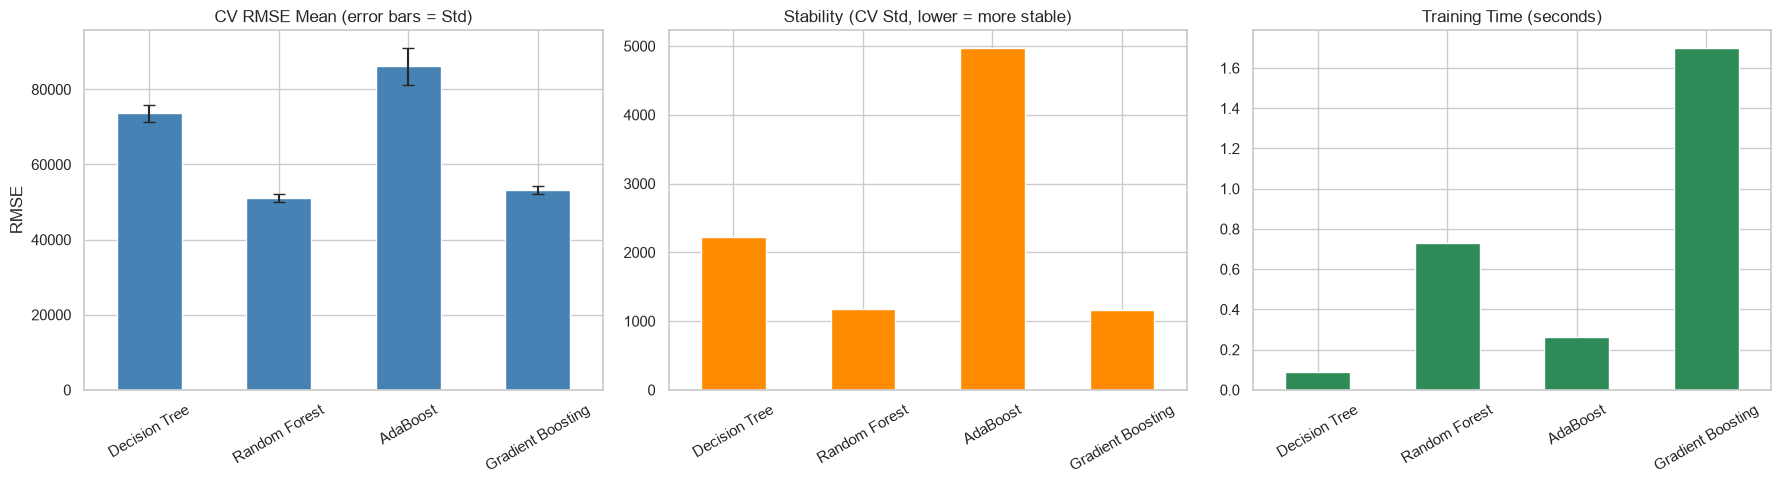

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

results_df["CV RMSE Mean"].plot(kind="bar", yerr=results_df["CV RMSE Std"],
                                ax=ax[0], color="steelblue", capsize=4)
ax[0].set_title("CV RMSE Mean (error bars = Std)")
ax[0].set_ylabel("RMSE")

results_df["CV RMSE Std"].plot(kind="bar", ax=ax[1], color="darkorange")
ax[1].set_title("Stability (CV Std, lower = more stable)")

results_df["Training Time (s)"].plot(kind="bar", ax=ax[2], color="seagreen")
ax[2].set_title("Training Time (seconds)")

for a in ax:
    a.set_xlabel("")
    a.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

MedInc        0.5250
AveOccup      0.1384
Latitude      0.0888
Longitude     0.0887
HouseAge      0.0545
AveRooms      0.0443
Population    0.0305
AveBedrms     0.0297
dtype: float64


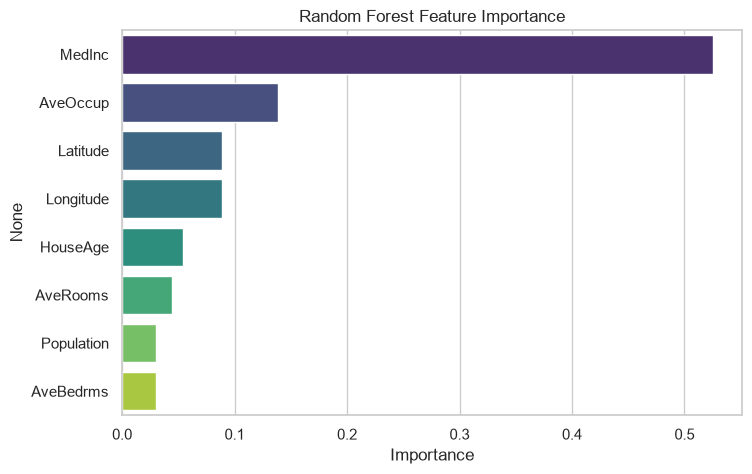

In [9]:
rf = models["Random Forest"]   # already trained on the full training data (Cell 8)

rf_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(rf_imp.round(4))

plt.figure(figsize=(8, 5))
sns.barplot(x=rf_imp.values, y=rf_imp.index, palette="viridis")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

MedInc        0.6043
AveOccup      0.1228
Longitude     0.1099
Latitude      0.0985
HouseAge      0.0341
AveRooms      0.0240
AveBedrms     0.0050
Population    0.0014
dtype: float64


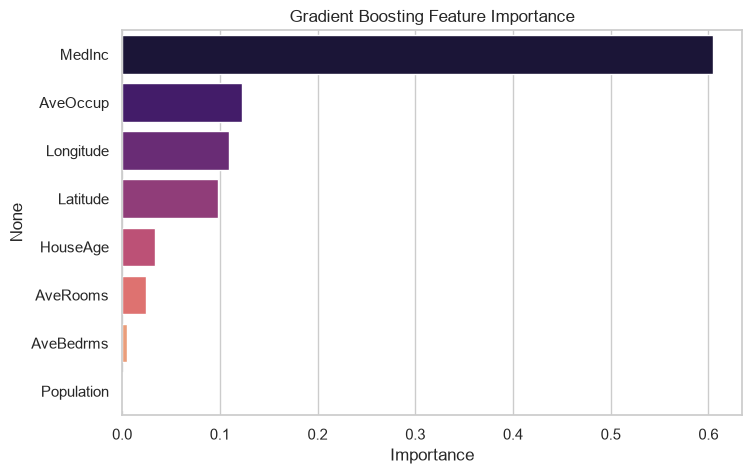

In [10]:
gb = models["Gradient Boosting"]

gb_imp = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=False)
print(gb_imp.round(4))

plt.figure(figsize=(8, 5))
sns.barplot(x=gb_imp.values, y=gb_imp.index, palette="magma")
plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.show()

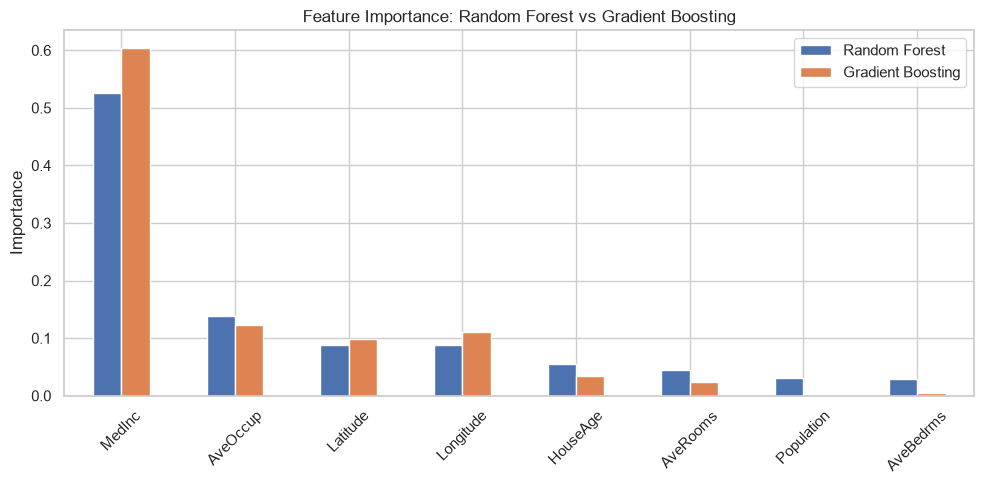

In [11]:
imp_df = pd.DataFrame({"Random Forest": rf_imp, "Gradient Boosting": gb_imp}).fillna(0)
imp_df = imp_df.sort_values("Random Forest", ascending=False)
imp_df.plot(kind="bar", figsize=(10, 5))
plt.title("Feature Importance: Random Forest vs Gradient Boosting")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

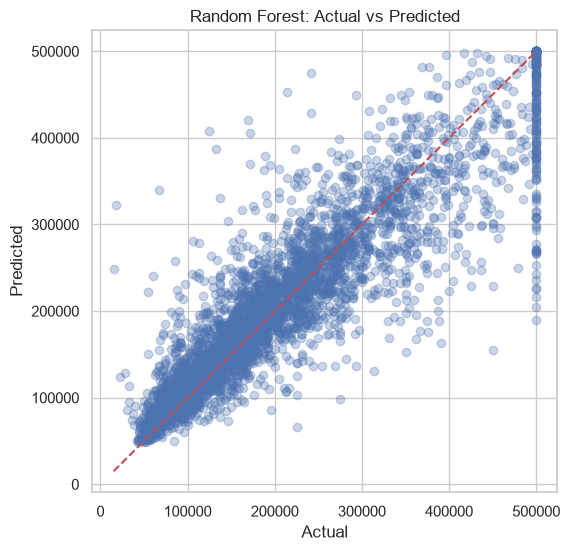

In [12]:
best_name = results_df["CV RMSE Mean"].idxmin()
best_model = models[best_name]
pred = best_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"{best_name}: Actual vs Predicted")
plt.show()

In [13]:
best_cv = results_df["CV RMSE Mean"].idxmin()
most_stable = results_df["CV RMSE Std"].idxmin()
fastest = results_df["Training Time (s)"].idxmin()

print("Lowest CV RMSE (best performance):", best_cv)
print("Lowest CV Std (most stable)      :", most_stable)
print("Fastest training                 :", fastest)

joblib.dump(models[best_cv], "best_model.pkl")
print(f"\nSaved '{best_cv}' as best_model.pkl")

Lowest CV RMSE (best performance): Random Forest
Lowest CV Std (most stable)      : Gradient Boosting
Fastest training                 : Decision Tree

Saved 'Random Forest' as best_model.pkl


## Observations
- The Decision Tree is a simple, interpretable and very fast baseline, but it has high variance and the highest CV RMSE.
- Random Forest reduces variance through bootstrap sampling (bagging) and feature randomisation, giving lower and more stable errors.
- AdaBoost focuses on poorly predicted samples, but its performance is usually between a single tree and Random Forest/Gradient Boosting.
- Gradient Boosting corrects errors sequentially and generally gives the best accuracy.
- Ensemble models need more training time than a single decision tree.
- Lower CV RMSE means better performance, and lower CV Std means better stability.
- Feature importance from Random Forest and Gradient Boosting shows the most influential predictors.

## Conclusion
Ensemble methods outperformed the single Decision Tree. Based on CV RMSE, stability, training time and interpretability (feature importance), **Gradient Boosting / Random Forest** is recommended for deployment (state which one your results favour). Accuracy alone should not decide the final model.